# Data processing: stocks {#sec-stocks}

This notebook mines and processes the stock data needed. Read the [README.md](README.md)/[@sec-intro] file for context about the project.

## Data and methodology

### Raw data

**Sources:** Intraday tick data from the [NYSE TAQ database](https://www.nyse.com/data-products/catalog/daily-taq). The relevant documentation is [Daily_TAQ_Client_Spec_v4.3.pdf](https://www.nyse.com/publicdocs/nyse/data/Daily_TAQ_Client_Spec_v4.3.pdf).

**Format:**

The data is can be easily stored as an SQLite3 database with the main table `trades` of the following schema:

```sql
CREATE TABLE trades (
    permno    INTEGER NOT NULL, -- Permanent number of the stock
    ts_ny     INTEGER NOT NULL, -- Timestamp in New York time (epoch seconds)
    price     REAL    NOT NULL, -- Price of the trade
    size      INTEGER NOT NULL, -- Size of the trade
    ex        TEXT    NOT NULL, -- Exchange code
    corr      TEXT    NOT NULL, -- Correction code
    ticker    TEXT    NOT NULL, -- Stock ticker symbol
    ambiguous INTEGER NOT NULL, -- Flag if the trade is ambiguous (0 or 1)
    PRIMARY KEY (permno, ts_ny)
) WITHOUT ROWID
```

Further documentation might be found looking for the relevant websites.

For the confection of this notebook, the data was given in a private Dropbox folder. The [TODO]() file contains a script to download it into the `data/stocks_raw/trades.db` file. 

**Qualities:**

The data is expected to have the qualities below. All are guaranteed by the data source.

- Within each `permno`, the data should be ordered by `ts_ny`. _Will be sorted_.
- There is one obs per minute, at the `00` seconds mark. Duplicates don't exist but missing minutes do. _Will be checked_.
- Data validity: `price` should never be negative or zero; `ex` and `corr` should have only the correct levels. _Anomalies are filtered out_.
- There should be data only for trading days. _Will be checked_.


### Methodology

First, some initial filters are applied (@sec-stocks-clean) and the raw data is saved in an optimized format. Then, the data is transformed from a `permno` ~ `second` ~ `price` data into a `permno` ~ `minute` ~ `log return` data (@sec-stocks-agg).

The calculations are done via [DuckDB](https://duckdb.org/) SQL queries.

## Code setup

Codes for debugging and running SQL inside notebooks:

In [22]:
%reset -f
import importlib

from IPython.core.magic import register_cell_magic
from pprint import pprint

import duckdb

queries_registered: dict[str, str] = {}

@register_cell_magic
def register_query(line: str, cell: str) -> None:
    query_name = line.strip()
    if not query_name:
        raise ValueError("You must provide a name for the query.")
    queries_registered[query_name] = cell

Setting up DuckDB infrastructure. The threads and memory limits are set following the memory constrains (16GB RAM) of the machine used to process the data.

In [23]:
%%register_query duckdb_infra
INSTALL sqlite;
LOAD sqlite;

-- DETACH db_trades;
ATTACH IF NOT EXISTS 'data/stocks_raw/trades.db' AS db_trades (TYPE SQLITE);

SET enable_progress_bar = true;
SET enable_progress_bar_print = true;

PRAGMA threads = 7;
PRAGMA memory_limit = '14GB';

In [24]:
#| output: false
duckdb.execute(queries_registered["duckdb_infra"])

Core modules:

In [78]:
import os
if os.path.basename(os.getcwd()) == "src": os.chdir("..")

import math

import polars as pl
import numpy as np

import src.utils as ut
import src.graphs as plot
from src.parameters import PARAMETERS as PARS
importlib.reload(ut)
importlib.reload(plot)

<module 'src.graphs' from 'c:\\Users\\ricar\\OneDrive\\A-Trabalho\\Freelance\\ra-distaso2026\\src\\graphs.py'>

## Initial data cleaning {#sec-stocks-clean}

An initial filter is applied before the processing logic, to remove uncessary data.

The column types are converted to ones that occupy less space in memory. See the [DuckDB types](https://duckdb.org/docs/current/sql/data_types/overview) for reference.

The is then saved into a [.parquet](https://parquet.apache.org/) file, a columnar storage format that is more efficient for analytical queries and compression than the original SQLite3 database. The row group size is chosen as approximately the median of observations per `permno`.

**Filters:**

- Exchanges: NYSE, NYSE-Arca, NASDAQ, and AMEX (code shares 10 and 11 at the CRSP database) (`ex IN ('P', 'N', 'Q', 'A')`). 
- Types of trades: regular trades (`corr = '00'`).
- Price should be positive (`price > 0`).
- Sample period(same as factors):
    - Range: 2001-01-02 to 2017-12-29. Stocks that are listed or delisted during this period are kept.
    - Hours: regular trading hours (09:30:00 - 15:59:59 ET).

**Formatting and data checking:**

- `permno`: is a 5-digit positive integer, and is stored as UINT32.
- `ts_ny`:
    - Is a seconds-since-1970-01-01 timestamp.
    - Our start date is 2001-01-02, which guarantees that the relevant observations are always positive.
    - There are no duplicates (`ts_ny > LAG(ts_ny)`).
    - There is only one observation per minute at the `00` mark `ts_ny % 60 != 0`, thus it is transformed into a minutes epoch.
    - Stored as UINT32, whose maximum date goes up to the year 10141.
- `price`: 14 integer digits and 6 decimal digits, stored as FLOAT8. Decimal(9, 6) could be used, but python's matrix libraries work better with floats. 

The two checks are stored into a validation column, and the final result is partitioned by it. Rows are partitioned into the `data/stocks_raw` directory's sub-folders `valid=pass/`, `valid==fail_not_minute/`, and `valid==fail_unordered_or_dupe/` (not committed to git).

This will be implemented via the following query:

In [26]:
%%register_query raw_to_clean

-- ?1: start epoch seconds (PARS.date_start)
-- ?2: end epoch seconds (PARS.date_end)

COPY (
    SELECT
        CAST(permno AS UINT32) AS permno,
        CAST(ts_ny // 60 AS UINT32) AS ts_min_ny,
        CAST(price AS FLOAT8) AS price,
        CASE
            WHEN (COUNT(*) OVER (PARTITION BY permno, ts_min_ny)) > 1
                AS is_duplicate
                THEN 'fail_duplicate'
            ELSE 'pass'
        END AS valid
    FROM db_trades.trades
    WHERE
        ts_ny BETWEEN ?1 AND ?2
        AND corr = '00'
        AND ex IN ('P', 'N', 'Q', 'A')
        AND (ts_ny % 86400) BETWEEN 34200 AND 57599 -- 09:30:00 to 15:59:59
        AND price > 0
    ORDER BY permno, ts_min_ny -- Costly but helps with querying later
) TO 'data/stocks_raw' (
    FORMAT PARQUET,
    COMPRESSION 'ZSTD',
    ROW_GROUP_SIZE 555000, -- Median of observations per permno
    PARTITION_BY (valid)
);

Then, we check if there are no data in the `valid==fail_duplicate/` folders, and move the `valid=pass/` data into the `data/stocks_raw` folder:

In [ ]:
#| execute: false
if False: # Only excecute once
    duckdb.execute(
        queries_registered["raw_to_clean"],
        [
            int(x.astype("datetime64[s]").astype(np.int64))
            for x in (PARS.date_start, PARS.date_end)
        ]
    )
    os.rename(
        "data/stocks_raw/valid=pass/data_0.parquet",
        "data/stocks_raw/trades_clean.parquet"
    )

if "valid==fail_duplicate/" in os.listdir("data/stocks_raw/"):
    raise ValueError(
        "There are invalid rows to be analyzed. Check the `data/stocks_raw/`'s"
        " subfolders"
    )

For utility, save the number of observations for each `permno`:

In [28]:
%%register_query counts_permno
COPY (
    SELECT 
        permno, 
        COUNT(*) as obs_count
    FROM 'data/stocks_raw/trades_clean.parquet'
    GROUP BY permno
    ORDER BY permno
) TO 'data/stocks_raw/counts_permno.csv' (HEADER, DELIMITER ',');

In [ ]:
#| execute: false
if False: # Only excecute once
    duckdb.execute(query = queries_registered["counts_permno"])

data_counts_permno = pl.read_csv("data/stocks_raw/counts_permno.csv")

The number of observations (1-minute blocks) for each (`permno`, day):

In [30]:
%%register_query counts_permno_day_1min
COPY (
    SELECT 
        permno,
        (ts_min_ny // (60 * 24)) as d,
        COUNT(*) as obs_count
    FROM 'data/stocks_raw/trades_clean.parquet'
    GROUP BY permno, d
) TO 'data/stocks_raw/counts_permno_day_1min.csv' (HEADER, DELIMITER ',');

In [ ]:
#| execute: false
#| output: false
if False: # Only excecute once
    duckdb.execute(query = queries_registered["counts_permno_day_1min"])

And the number of 5-minute blocks with data, for each (`permno`, day):

In [32]:
%%register_query counts_permno_day_5min
COPY (
    SELECT 
        permno,
        (ts_min_ny // (60 * 24)) as d,
        COUNT(DISTINCT ts_min_ny // 5) as obs_count
    FROM 'data/stocks_raw/trades_clean.parquet'
    GROUP BY permno, d
) TO 'data/stocks_raw/counts_permno_day_5min.csv' (HEADER, DELIMITER ',');

In [ ]:
#| execute: false
#| output: false
if False: # Only excecute once
    duckdb.execute(query = queries_registered["counts_permno_day_5min"])

Saving the data, and filling missing days within the permno lifetime with `obs_count = 0`:

In [34]:
data_counts_min = {
    x: pl.read_csv(f"data/stocks_raw/counts_permno_day_{x}min.csv")
    for x in [1, 5]
}

## Dates analysis {#sec-stocks-day-fullness}

Now, we turn to analyzing the distribution of observations within a day for a stock. We want to remove stocks that have too many days with none or too few observations.


### Trading days

First, we need to define what is a missing day, that is, what are the trading days. In [src/parameters.py](src/parameters.py), we calculate the full (`9:30` $\to$ `16:00`) trading days as the union of: days with full factor data, days as described by the `exchange_calendars` python package, and days described by the `pandas_market_calendars` package. But, there might be some days that were not full trading days for the stocks in our sample.

First, lets check if any of the stocks have date for non-trading days. It is expected that there are data for non-full trading days.

In [35]:
data_days = data_counts_min[1].with_columns(
    pl.from_epoch(pl.col("d"), time_unit = "d")
)

days_unique = np.unique(data_days["d"].to_numpy().astype("datetime64[D]"))

if not np.isin(days_unique, PARS.trading_days).all():
    raise ValueError("There are days in the data that are not trading days.")

if not np.isin(days_unique, PARS.trading_days_factors).all():
    print("There are days in the data that are not full trading days.")

There are days in the data that are not full trading days.


The river plot below shows, for each day, the quantiles of the number of minutes with data for each stock, divided by the total number of minutes in a trading day (390).

The blue dots show days where the factor data didn't had all minutes with data, which at first, is our truth source for non-full days. The gray dots show the days where the median is $-0.1$ points smaller than its 5-day rolling mean, that is, possible extraordinary trading days.

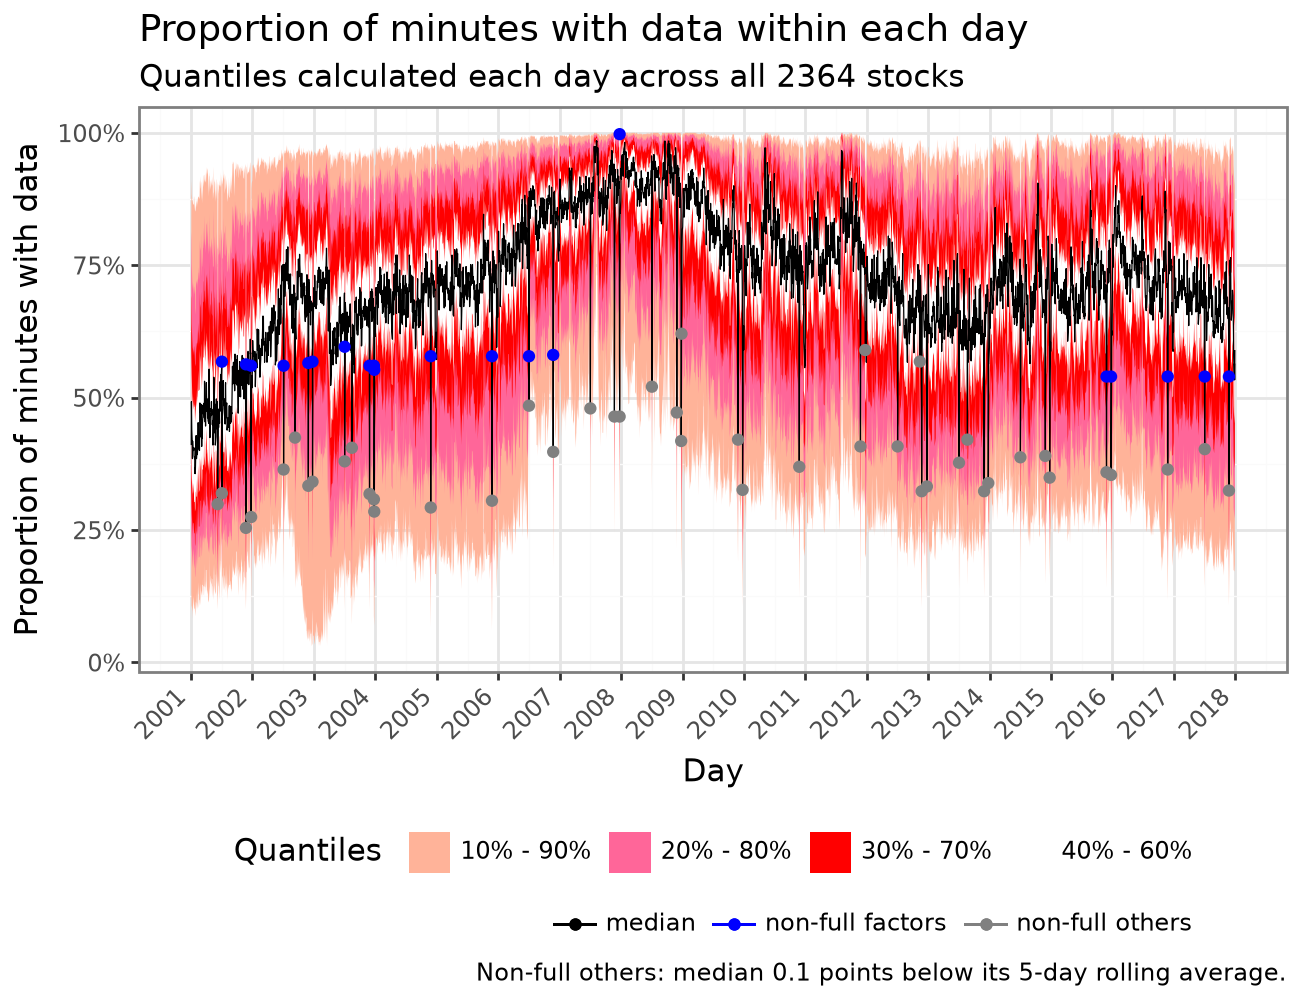

In [36]:
#| out-width: "85%"

data_days_fill = (
    data_days
    .with_columns(pl.col("obs_count") / PARS.blocks_1min)
    .group_by("d")
    .agg(
        median = pl.median("obs_count"),
        **{
            f"q{q}": pl.quantile("obs_count", q / 10)
            for q in [4, 6, 3, 7, 2, 8, 1, 9]
        }
    )
    .sort("d")
)

plot.day_fullness_river(data_days_fill, data_counts_permno.shape[0])

The average median is $\approx 0.72$. We can see many outlier dates with very low coverage, which are likely to be extraordinary trading days. Still, some of these days are not within the list of full trading days, as shown below. Individually checking the dates, they still seem to be extraordinary trading days, but that have data present for the factors. They will be included in the non-full trading days list.

In [37]:
days_low_obs = (
    data_days_fill
    .with_columns(median_rw = pl.col("median").rolling_mean(8))
    .filter(pl.col("median") - pl.col("median_rw") <= - 0.1)
    ["d"].to_numpy()
)

print(f"Number of days with low observations: {len(days_low_obs)}")
print(ut.format_days_byyear(days_low_obs[
    np.isin(days_low_obs, PARS.trading_days_factors)
]))

Number of days with low observations: 52

- 2001: 06-08, 
- 2002: 09-11, 
- 2003: 08-15, 
- 2005: 12-23, 
- 2007: 07-03, 11-23, 
- 2008: 07-03, 11-28, 12-24, 12-26, 
- 2009: 11-27, 12-24, 
- 2010: 11-26, 12-27, 
- 2011: 08-15, 11-25, 12-23, 12-27, 
- 2012: 07-03, 11-12, 11-23, 12-24, 
- 2013: 07-03, 08-22, 11-29, 12-24, 
- 2014: 07-03, 11-28, 12-24, 12-26, 
- 2015: 10-12, 
- 2016: 12-23, 


### Days with missing data

Now, on to checking which days have missing data. Missing days within the PERMNO's lifetime are filled with 0. For each 1-minute and 5-minute block, we plot:

1. The histogram of the number of observed blocks for each day, across all days of all stocks.
2. Boxplots of the proportion of days with more observed blocks than some threshold $\tau$, across all stocks, for multiple thresholds.

In [38]:
data_filled_min = {
    x: ut.fill_missing_days(data_counts_min[x])
    for x in [1, 5]
}

### 1-Minute blocks

For $\tau = 78$, there are $1,292$ stocks with at most $2.5\%$ non-full days.

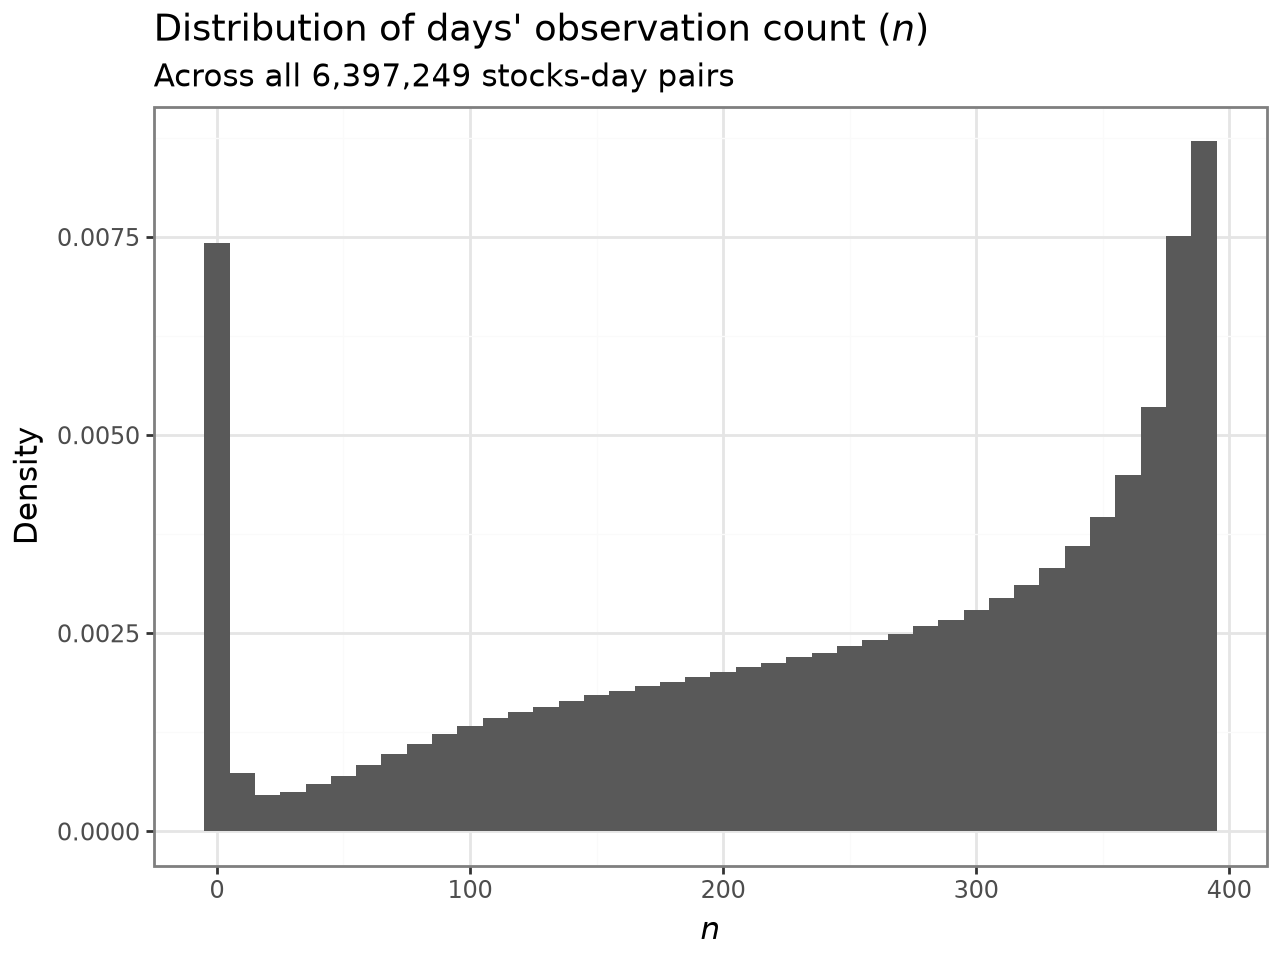

In [49]:
plot.day_fullness_hist(data_filled_min[1])

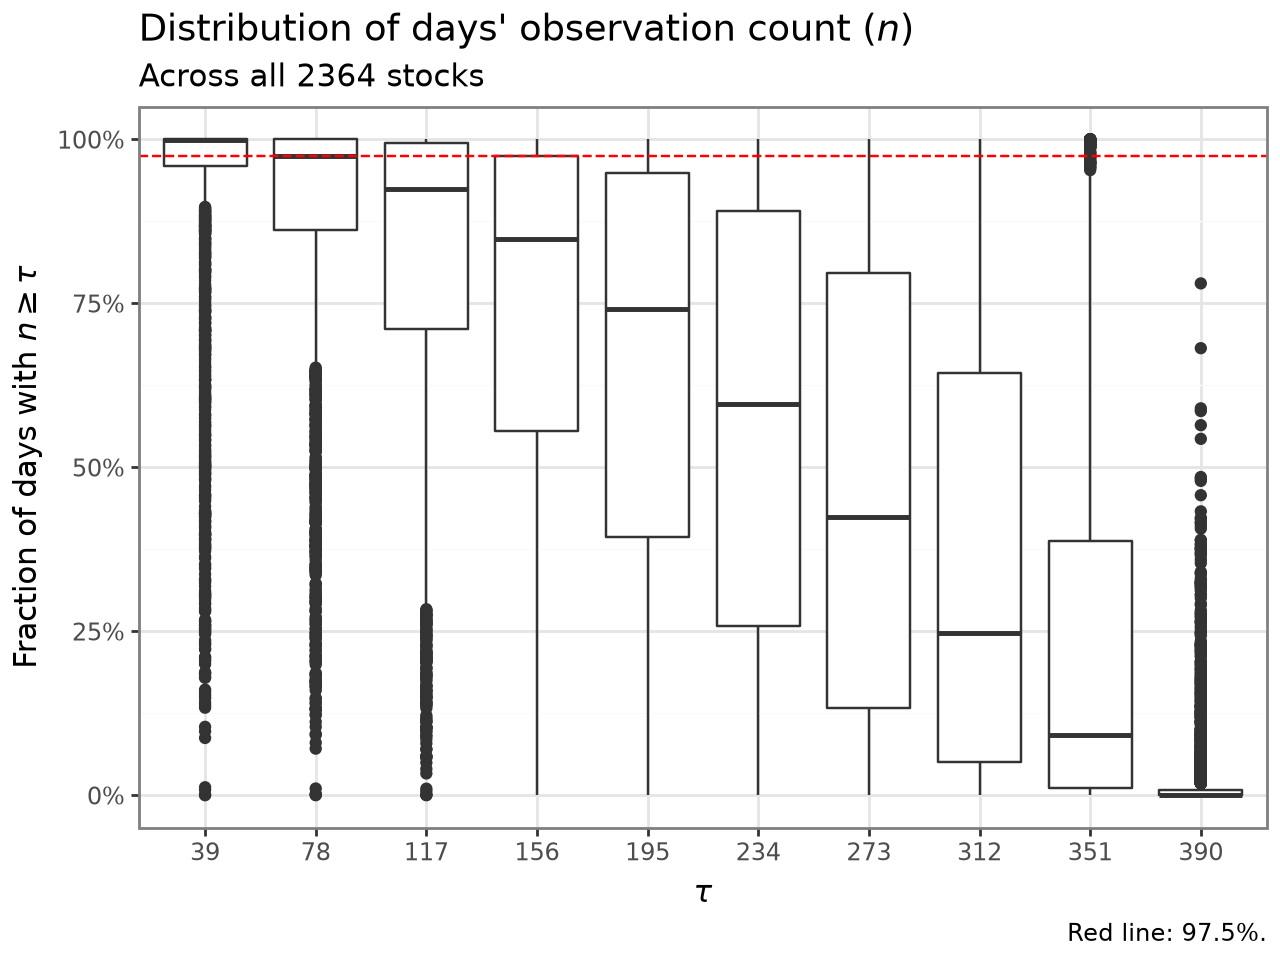

In [ ]:
plot.day_fullness_box(data_filled_min[1], 1, data_counts_permno.shape[0])

To better understand how to filter stocks, consider the following heatmap:

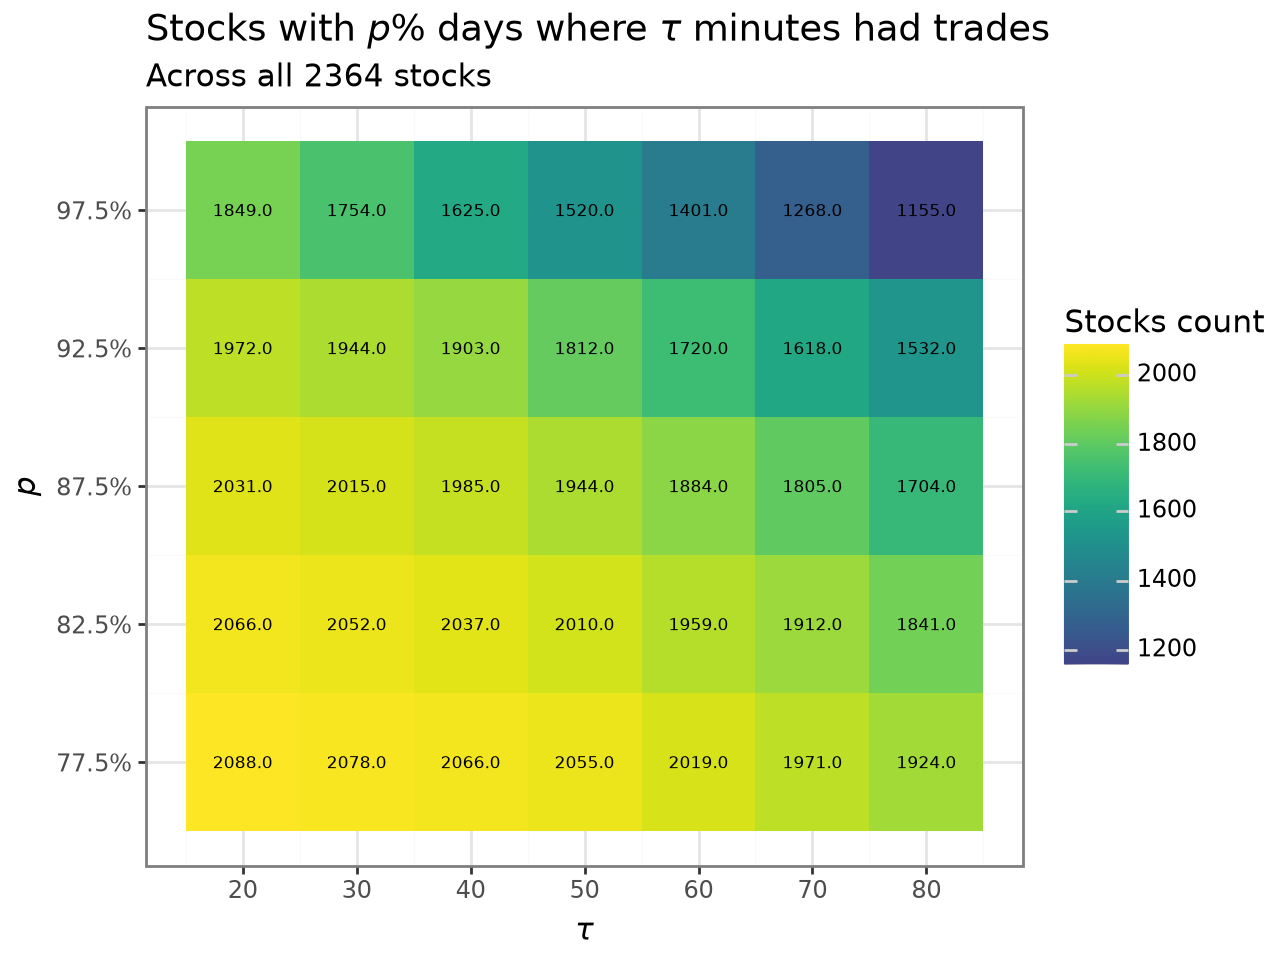

In [84]:
plot.day_fullness_matrix(
    data_filled_min[1],
    [20, 30, 40, 50, 60, 70, 80],
    [0.775, 0.825, 0.875, 0.925, 0.975],
    data_counts_permno.shape[0]
)

### 5-minute blocks

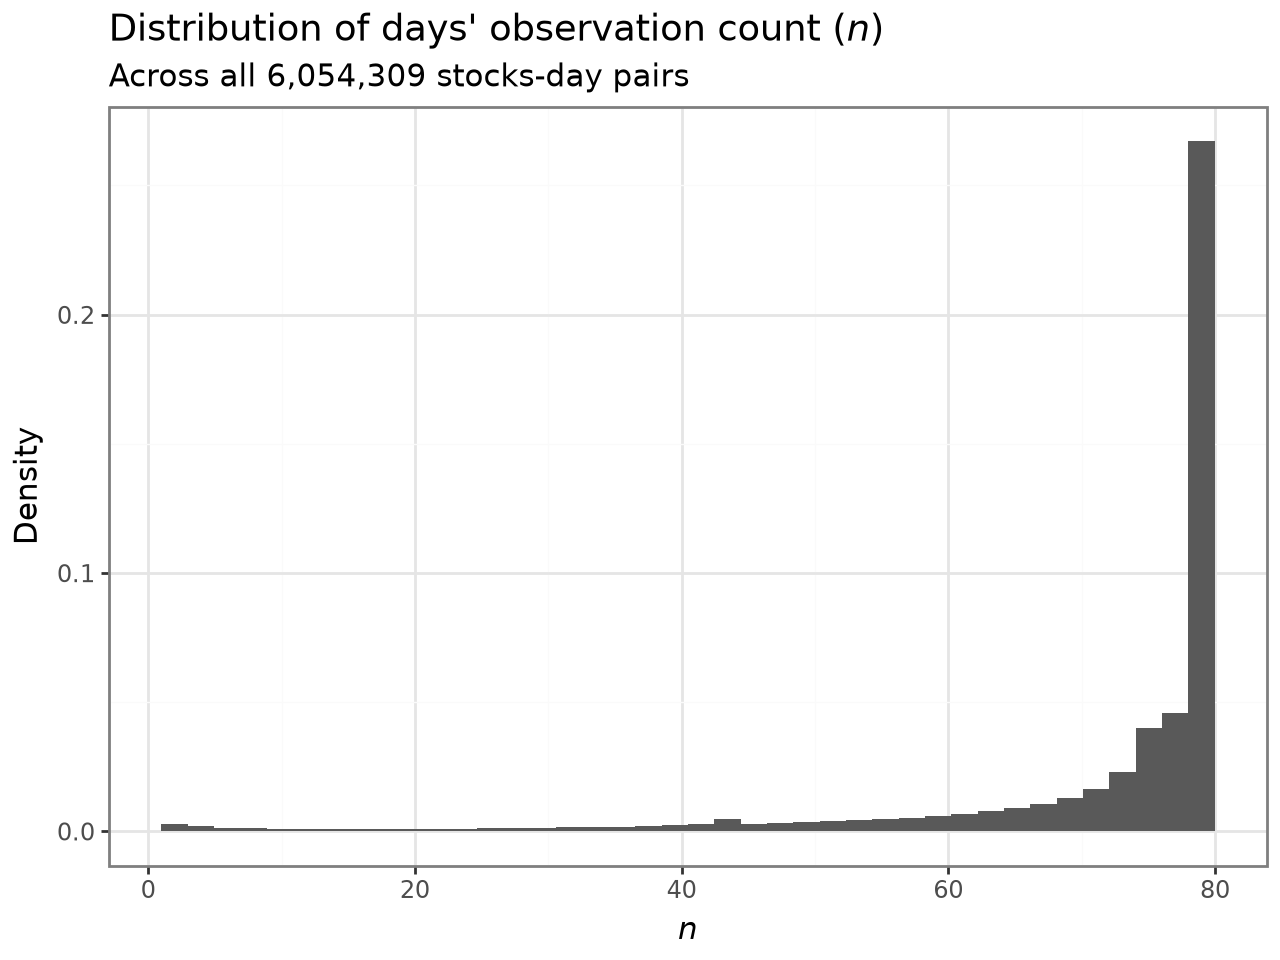

In [ ]:
plot.day_fullness_hist(data_counts_min[5])

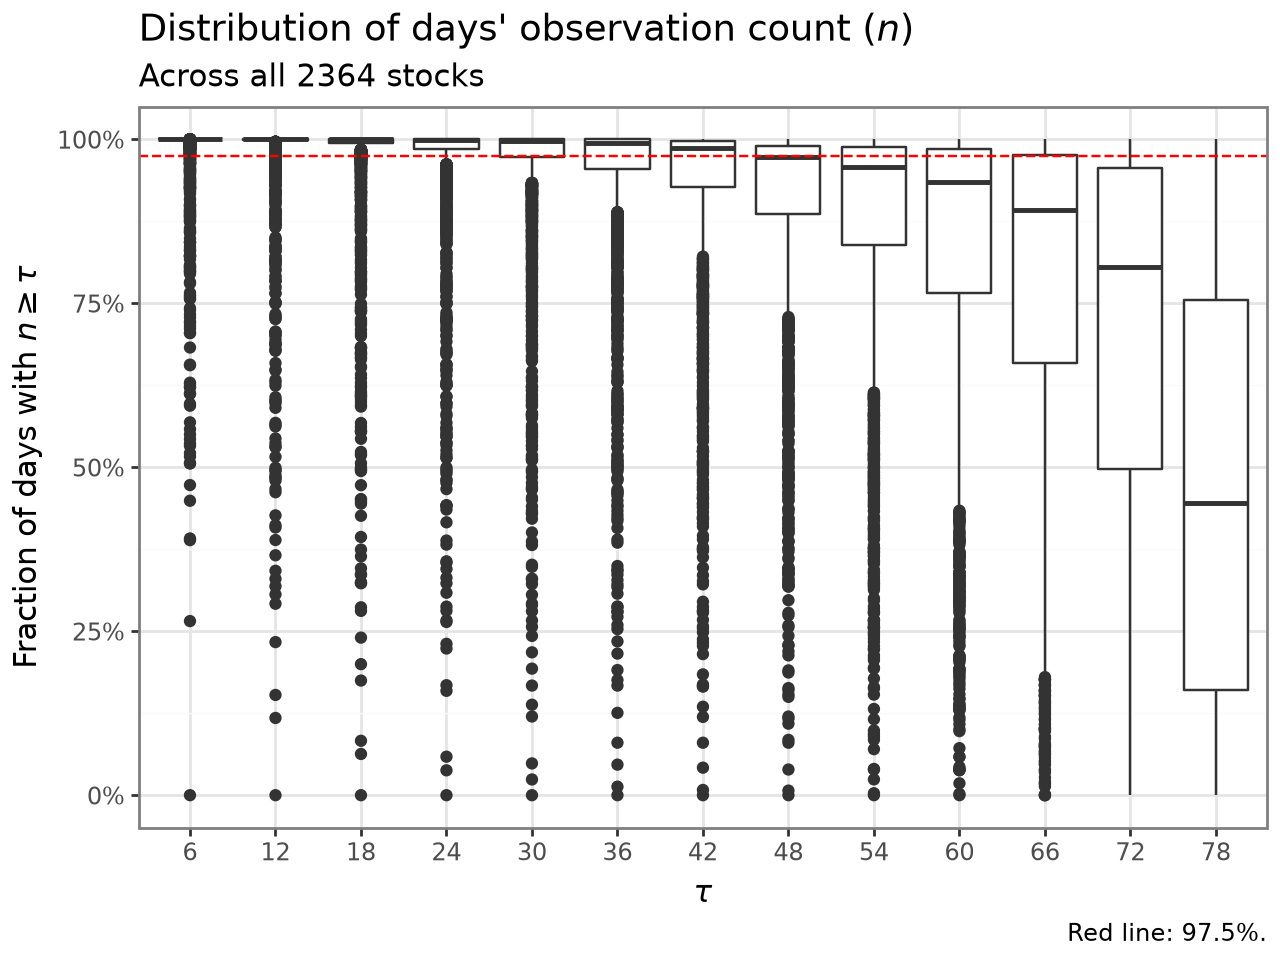

In [ ]:
plot.day_fullness_box(data_counts_min[5], 5, data_counts_permno.shape[0])

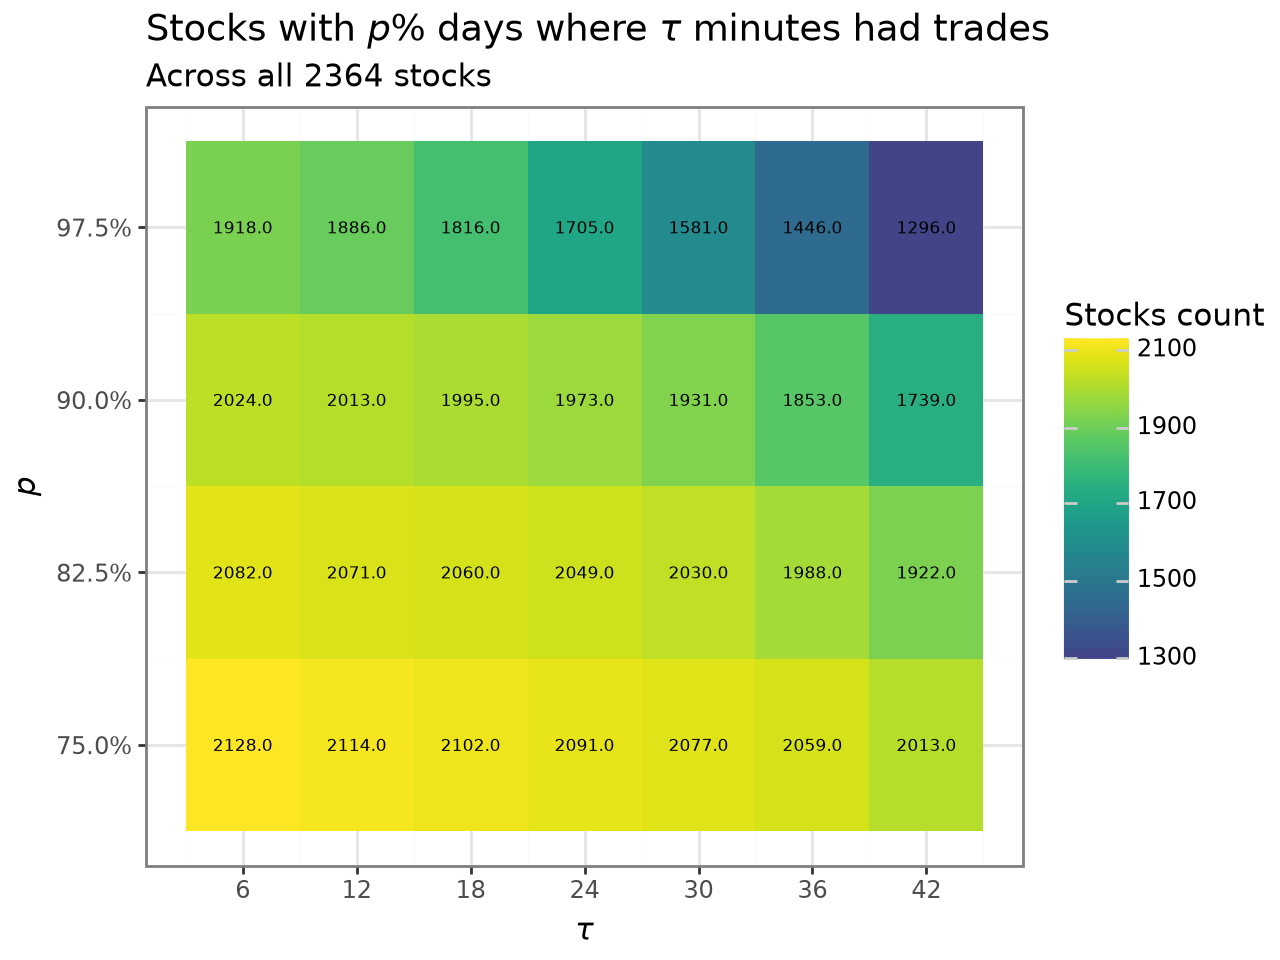

In [ ]:
plot.day_fullness_matrix(
    data_filled_min[5],
    [6, 12, 18, 24, 30, 36, 42],
    [0.775, 0.825, 0.875, 0.925, 0.975],
    data_counts_permno.shape[0]
)

## Aggregation of 1-minute log returns {#sec-stocks-agg}

To aggregate the data, for each `permno`:

1. For each 1-minute block $m$: get the last seen price before the end of $m$'s block, $p_m$.
2. Minimal liquidity filter: at most 2.5% of the trading days (excluding pre-listing and post-delisting days) have less than 78 minutes with data.
3. Calculate $r^1_m = \ln(p_t / p_{m-1})$.
4. Exclude the first return of the day to remove overnight effects.
5. Exclude non-full trading days..
- Save a [data/stocks_1min_returns.parquet](data/stocks_1min_returns.parquet) file with the columns `permno`, `ts_min_ny`, and `log_return`.

Some notes:

- As checked in the raw data, the observations are already at the minute level with no duplicates, so we don't need to actually do any aggregation.
- The "last seen price" is not the undisputed correct price to use for calculating returns. Other methods include the midpoint of the bid-ask spread and the volume-weighted average price.
- We could save the information of how many observations were within each minute block, but that information is not needed at the moment.

The transformation could be done with either DuckDB or Polars, both multithreaded. It also could be done in chunks if the data is too big. Polars seems to deal better with the latter, but the following DuckDB code is written to process the data in one go. See the appendix for alternatives.

In [15]:
%%register_query trade_returns_aggregation_chunked

-- ?1: list of permnos to filter
-- ?2: chunk file path

COPY (
    WITH
    trades_by_min AS (
        SELECT
            permno,
            ts_min_ny,
            price,
            (ts_min_ny // (60 * 24)) AS d
        FROM 'data/stocks_raw/trades_clean.parquet'
        WHERE
            permno BETWEEN ?1[0] AND ?1[-1]
    )
    SELECT
        permno,
        ts_min_ny,
        LN(price / LAG(price, 1) OVER w) AS log_return
    FROM trades_by_min
    WINDOW w AS (PARTITION BY permno, d ORDER BY ts_min_ny)
    QUALIFY 
        LAG(price, 1) OVER w IS NOT NULL
)
TO ?2 (
    FORMAT PARQUET,
    COMPRESSION 'ZSTD',
    ROW_GROUP_SIZE 555000
);

In [ ]:
#| output: false
duckdb.execute(queries_registered["trade_returns_aggregation_chunked"])

The data will be forward filled with $0$ return on minutes with no trades, and will also be aggregated to the 5-minute level. But, storing these to disk is unneeded, and it is better to create the variations on-the-fly.

### Visualizing raw data and aggregation

Lets visualize the work to have a first look at the data and check if everything is as expected.

First, lets sample some random stocks.

In [42]:
vis_permnos = data_counts_permno["permno"].sample(4).to_numpy()

We could visualize the original raw data, but very few operations were done on it. Still, one could run the following SQL and polars codes to generate a dataset to visualize:

```sql
%%register_query raw_permno_sample

-- ?1: list of integer permnos to filter

SELECT
    CAST(permno AS UINT32) AS permno,
    CAST(ts_ny // 60 AS UINT32) AS ts_min_ny,
    CAST(price AS FLOAT8) AS price,
FROM db_trades.trades
WHERE
    permno IN ?1
```

```python
data_permno_raw = (
    duckdb.sql(queries_registered["raw_permno_sample"], params = [vis_permnos.tolist()])
    .pl()
    .with_columns(
        datetime = pl.from_epoch(pl.col("ts_min_ny") * 60, time_unit = "s")
    )
    .select(["permno", "datetime", "price"])
)
```

The code below plots the clean prices and the returns aggregation. Both are aggregated to the 30-day level, to make the relationship between the two clearer.

The relationship between the two looks as expected.

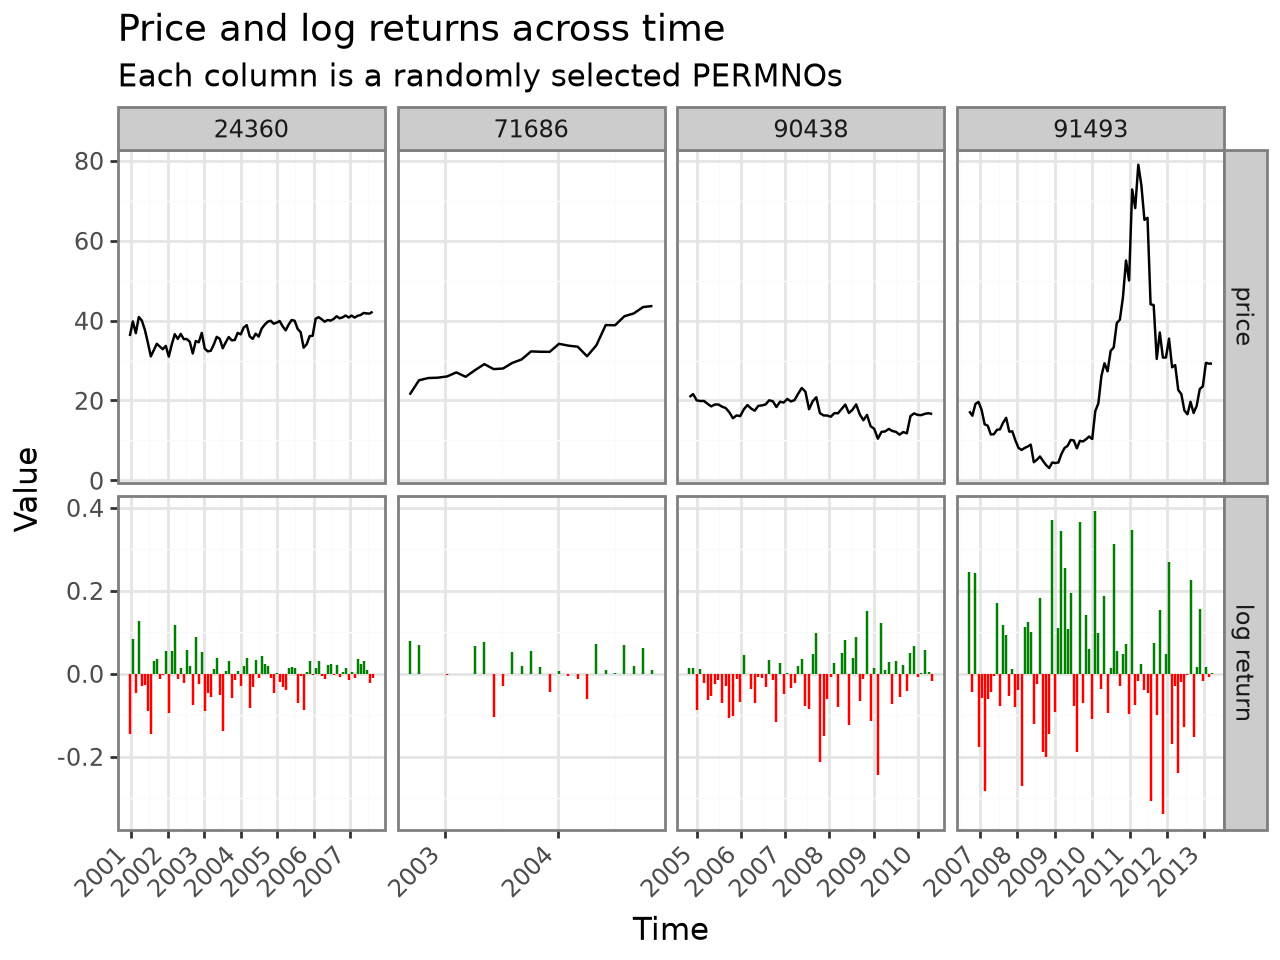

In [ ]:
plot.prices_returns(
    pl.scan_parquet("data/stocks_raw/trades_clean.parquet")
    .filter(pl.col("permno").is_in(vis_permnos))
    .collect(),
    pl.scan_parquet("data/stocks_1min_returns.parquet")
    .filter(pl.col("permno").is_in(vis_permnos))
    .collect()
)

## Appendix

If the calculations above are too harsh for the available machine's memory, one can do it in chunks of `permno` values. The chunks are definde below, striving for a balance in the number of rows in each chunk. Each chunk has 7% of the rows, a number defined by the memory constrains (16GB RAM) of the machine used to process the data.

In [ ]:
agg_chunk_fraction = 0.07
agg_chunk_cutoff = math.floor(
    int(data_counts_permno["obs_count"].sum()) * agg_chunk_fraction * 0.95
) # 0.95 avoids last chunk being too small
agg_total_chunks = math.ceil(1 / agg_chunk_fraction)

chunks = []
current_stock = 0

for i in range(agg_total_chunks):
    c = []
    c_rows = 0
    while c_rows < agg_chunk_cutoff and current_stock < len(data_counts_permno):
        c.append(data_counts_permno["permno"][current_stock])
        c_rows += data_counts_permno["obs_count"][current_stock]
        current_stock += 1
    if i == agg_total_chunks - 1:
        c.extend(data_counts_permno["permno"][current_stock:].to_list())
    chunks.append(c)

if sum(len(c) for c in chunks) != len(data_counts_permno):
    raise ValueError("Some stocks are missing from the chunks.")

print(f"Number of chunks: {len(chunks)}")
print("Number of stocks in each chunk: ", end = "")
pprint([len(c) for c in chunks], width = 50, compact = True)
print("Rows/1M per chunk (approx): ", end = "")
pprint([
    round(
        sum(data_counts_permno.filter(pl.col("permno").is_in(c))["obs_count"])
        / 1_000_000,
        1
    )
    for c in chunks
], width = 50, compact = True)

Number of chunks: 15
Number of stocks in each chunk: [168, 328, 103, 106, 111, 110, 106, 141, 142, 150,
 166, 164, 163, 190, 216]
Rows/1M per chunk (approx): [107.0, 108.1, 107.7, 107.6, 107.1, 107.5, 107.0,
 106.9, 107.3, 107.7, 107.9, 106.9, 107.1, 107.0,
 103.3]


In [ ]:
data_trades_lazy = pl.scan_parquet(
    "data/stocks_raw/trades_clean.parquet",
    parallel = "row_groups",
    low_memory = False
)

def lazy_pipeline_agg(chunk: list[int]) -> pl.LazyFrame:
    trading_days_extra = PARS.trading_days[
        ~ np.isin(PARS.trading_days, PARS.trading_days_final)
    ].astype("int32")

    pipeline = (
        data_trades_lazy
        .filter(pl.col("permno").is_between(chunk[0], chunk[-1]))
        #.sort(["permno", "ts_min_ny"]) # Already sorted
        .with_columns(
            d = (pl.col("ts_min_ny") // (60 * 24))
        )
        .with_columns(
            log_return = (
                pl.col("price") / (
                    pl.col("price")
                    .shift(1).over(["permno", "d"]) # Never cross days
                    # order_by = "ts_min_ny" is unneeded
                )
            ).log(),
        )
        .filter(
            pl.col("log_return").is_not_null() # Excludes first null return of day
            & (~ pl.col("ts_min_ny").is_in(trading_days_extra))
        )
        .select(["permno", "ts_min_ny", "log_return"])
    )
    return pipeline

For each chunk, the pipeline is executed and the results are saved in a parquet file such as [data/stocks_1min_returns/chunk_1.parquet](data/stocks_1min_returns/chunk_1.parquet):

In [ ]:
#| execute: false
#| output: false
if False: # Only excecute once
    for i, chunk in enumerate(chunks[-1:]):
        print(f"Processing chunk {i+1}/{len(chunks)} with {len(chunk)} permnos")
        lazy_pipeline_agg(chunk).sink_parquet(
            f"data/stocks_1min_returns/chunk_{i}.parquet",
            compression = "zstd",
            engine = "streaming",
            row_group_size = 555_000
        )

Processing chunk 1/15 with 216 permnos


An alternative to the code for Polars is the DuckDB code below.

In [ ]:
%%register_query trade_returns_aggregation_chunked

-- ?1: list of permnos to filter
-- ?2: chunk file path

COPY (
    WITH
    trades_by_min AS (
        SELECT
            permno,
            ts_min_ny,
            price,
            (ts_min_ny // (60 * 24)) AS d
        FROM 'data/stocks_raw/trades_clean.parquet'
        WHERE
            permno BETWEEN ?1[0] AND ?1[-1]
    )
    SELECT
        permno,
        ts_min_ny,
        LN(price / LAG(price, 1) OVER w) AS log_return
    FROM trades_by_min
    WINDOW w AS (PARTITION BY permno, d ORDER BY ts_min_ny)
    QUALIFY 
        LAG(price, 1) OVER w IS NOT NULL
)
TO ?2 (
    FORMAT PARQUET,
    COMPRESSION 'ZSTD',
    ROW_GROUP_SIZE 555000
);

In [ ]:
#| execute: false
#| output: false
if False: # Run polars instead
    for i, chunk in enumerate(chunks[-1:]):
        print(f"Processing chunk {i+1}/{len(chunks)} with {len(chunk)} permnos")
        duckdb.execute(
            queries_registered["trade_returns_aggregation_chunked"],
            [chunk, f"data/stocks_1min_returns/chunk_{i}.parquet"]
        )

Processing chunk 1/15 with 216 permnos


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))